unmix them pixels yooo

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import joblib
from math import ceil
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
import unmix_pixels as unmix

In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

In [3]:
# Define functions
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['font.size'] = 9

def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return (y)

def make_categorical_palette(series):
    """
    Create a categorical colour dictionary from unique values in a column,
    using the Tab20 palette. Automatically handles >20 categories by cycling.
    """
    unique_vals = pd.unique(series)

    # Get the Tab20 palette (20 distinct colours)
    base_colors = plt.cm.tab20.colors

    # Cycle through colours if categories > 20
    color_cycle = itertools.cycle(base_colors)

    # Build dictionary
    palette = {val: next(color_cycle) for val in unique_vals}

    return palette
    
def plot_multi_result(
    x_array,
    y_array,
    alpha,
    colour,
    metric,
    cmap,
    fig_title,
    x_axis_label,
    y_axis_label,
    stats_values,
    line_1_1,
    sensor_code,
    class_code,
    colour_mode="continuous",
    type="scatter",
    h_lines=None,
    save=False,
    output_dir=None,
    output_name=None,
    figsize=(2, 3),
    figrows=None,
    annotation_xy=(0.05, 0.8)
):
    # --- Prepare data ---
    if isinstance(y_array, pd.DataFrame):
        y_array = y_array.values
    if isinstance(stats_values, pd.DataFrame):
        stats_values = stats_values.values

    # --- Layout ---
    n_cols = x_array.shape[1]
    if figrows is not None:
        n_rows = figrows
        fig_cols = ceil(n_cols / n_rows)
    else:
        n_rows = ceil(n_cols / 2)
        fig_cols = 2

    fig, axes = plt.subplots(
        n_rows, fig_cols,
        figsize=(fig_cols * figsize[0], n_rows * figsize[1]),
        sharex=True, sharey=True
    )
    axes_flat = np.array(axes).flatten()  # Always 1D, regardless of shape
    fig.tight_layout(pad=2)

    # --- Colour mapping ---
    if colour_mode == "categorical":
        mask = ~np.isnan(colour)
        x_array = x_array.iloc[mask, :]
        y_array = y_array[mask, :]
        colour_dict = make_categorical_palette(colour)
        c_values = [colour_dict[v] for v in colour[mask]]

    elif colour_mode == "continuous":
        c_values = np.asarray(colour)

    else:
        raise ValueError("colour_mode must be 'categorical' or 'continuous'.")

    # --- Subplot loop ---
    shared_mappable = None
    letters = [chr(ord('A') + i) for i in range(n_cols)]  # ['A', 'B', 'C', ...]

    for i, col_name in enumerate(x_array.columns):
        ax = axes_flat[i]

        # Plot
        if type == "scatter":
            shared_mappable = ax.scatter(
                x_array[col_name], y_array[:, i],
                alpha=alpha, c=c_values,
                cmap=cmap if colour_mode == "continuous" else None
            )
        elif type == "hexbin":
            shared_mappable = ax.hexbin(
                x=x_array[col_name], y=y_array[:, i],
                gridsize=50, bins="log", cmap=cmap
            )

        # Subplot letter (top-left corner, above annotation)
        ax.text(0.9, 0.1, letters[i], transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top')

        # Axis labels
        ax.set_xlabel(f"{x_axis_label} of {col_name.replace('_', ' ')}")
        ax.set_ylabel(y_axis_label)

        # Stats annotation
        if stats_values is not None:
            ax.annotate(
                r'$\mathregular{R^2}$' f": {stats_values['R2'][i]:.3f}\nMAE: {stats_values['MAE'][i]:.3f}",
                xy=annotation_xy, xycoords="axes fraction"
            )

        # 1:1 line
        if line_1_1:
            ax.axline((0, 0), slope=1, color="lightgrey", linestyle="--")

        # Horizontal threshold lines
        if h_lines is not None:
            for h in h_lines:
                ax.axhline(y=h[0], color=h[1], linestyle=":")

    # Hide unused subplots
    for ax in axes_flat[n_cols:]:
        ax.set_visible(False)

    # --- Colourbar or legend ---
    if colour_mode == "continuous":
        cbar = fig.colorbar(shared_mappable, ax=axes_flat[:n_cols].tolist(),
                            shrink=1, aspect=50, pad=0.015)
        cbar.set_label("Pixel count")

    elif colour_mode == "categorical":
        handles = [
            plt.Line2D([0], [0], marker='o', linestyle='', color=c, label=str(v))
            for v, c in colour_dict.items()
        ]
        fig.legend(handles=handles, title="Categories", loc="right", bbox_to_anchor=(1.15, 0.5))

    fig.suptitle(fig_title, y=1, fontsize=11)

    # --- Save ---
    if save:
        if not sensor_code or not class_code:
            raise ValueError("sensor_code and class_code must be provided to save.")
        output_dir = output_dir or "./"
        os.makedirs(output_dir, exist_ok=True)
        for ext in ("svg", "png"):
            fig.savefig(os.path.join(output_dir, f"{output_name}.{ext}"), bbox_inches="tight")

    plt.show()

def plot_multi_result_huge(
    x_array,
    y_array,
    alpha,
    colour,
    metric,
    cmap,
    fig_title,
    x_axis_label,
    y_axis_label,
    stats_values,
    line_1_1,
    sensor_code,
    class_code,
    annotation_xy,
    colour_mode = "continuous",
    type="scatter",
    h_lines=None,
    save=False,
    output_dir=None,
    output_name=None,
    figsize=3,
    figrows = None,
):
    # --- Prepare data ---
    if isinstance(y_array, pd.DataFrame):
        y_array = y_array.values
    if isinstance(stats_values, pd.DataFrame):
        stats_values = stats_values.values

    n_cols = x_array.shape[1]
    if figrows is not None:
        n_rows = figrows
        fig_cols = n_cols // n_rows if n_cols%n_rows == 0 else n_cols // n_rows + 1
    else:
        n_rows = n_cols // 2 + n_cols % 2
        fig_cols = 2

    # Create a figure and subplot axes
    fig, ax = plt.subplots(
        n_rows,
        fig_cols,
        figsize=(10, n_rows * figsize),
        sharex=True,
        sharey=True
    )
    ax = np.atleast_2d(ax)
    fig.tight_layout(pad=1.5)

    shared_mappable = None

    # --- Determine colour mapping ---

        
    if colour_mode == "categorical":
        # mask out nan values
        mask_nan = np.isnan(colour)
        x_array = x_array.iloc[~mask_nan,:]
        y_array = y_array[~mask_nan, :]

        # Build palette dict
        colour_dict = make_categorical_palette(colour)

        # Build per-point colour vector 
        c_values = []
        for v in colour[~mask_nan]:
            c_values.append(colour_dict[v])


    elif colour_mode == "continuous":
        c_values = np.asarray(colour)

    else:
        raise ValueError("Colour mode must be 'categorical' or 'continuous'.")

    # Sublot loop
    for col in range(n_cols):
        col_name = x_array.columns[col]
        row_i, col_i = divmod(col, fig_cols)
        
        if type == "scatter":
            sc = ax[row_i, col_i].scatter(
                x_array[col_name],
                y_array[:, col],
                alpha=alpha,
                c=c_values,
                cmap=cmap if colour_mode == "continuous" else None
            )
            # if shared_mappable is None:
            shared_mappable = sc

        elif type == "hexbin":
            hb = ax[row_i, col_i].hexbin(
                x=x_array[col_name],
                y=y_array[:, col],
                gridsize=50,
                bins="log",
                cmap=cmap
            )
            # if shared_mappable is None:
            shared_mappable = hb
        
        ax[row_i, col_i].annotate(
                col_name.replace("_"," ").capitalize(),
                xy=(0.0, 1.02),
                xycoords="axes fraction",
                color = "red",
                fontsize = 10 if len(col_name) < 18 else 9
            )

        if stats_values is not None:
            ax[row_i, col_i].annotate(r'$\mathregular{R^2}$' f": {stats_values["R2"][col]:.3f}\nMAE: {stats_values["MAE"][col]*100:.1f}",
                # f"R2: {stats_values['R2'][col]:.3f}\nMAE: {stats_values[metric][col]*100:.1f}",
                xy=annotation_xy,
                xycoords="axes fraction",
                color= "crimson",
            )

        # Add 1:1 line if desired
        if line_1_1:
            ax[row_i, col_i].axline((0, 0), slope=1, color="lightgrey", linestyle="--")

        # Add threshold lines if provided
        if h_lines is not None:
            for h in h_lines:
                ax[row_i, col_i].axhline(y=h[0], color=h[1], linestyle=":")

    # Hide last empty subplot if odd number of columns
    if n_cols % figrows != 0:
        empties = fig_cols - (n_cols % fig_cols) +1
        for empty in range(1, empties):
            ax[-1, -empty].set_visible(False)
            ax[-2, -empty].set_xlabel(x_axis_label, fontsize = 10)

    # Add colourbar or legend
    if colour_mode == "continuous":
        cbar = fig.colorbar(shared_mappable, ax=ax.ravel().tolist(), shrink=1, aspect = 50, pad = 0.015)
        cbar.set_label("Pixel count")

    elif colour_mode == "categorical":
        handles = [
            plt.Line2D([0], [0], marker='o', linestyle='', color=colour_dict[val], label=str(val))
            for val in colour_dict
        ]
        fig.legend(handles=handles, title="Categories", loc="right", bbox_to_anchor=(1.15, 0.5))

    
    for row in range(figrows):
        ax[row, 0].set_ylabel(y_axis_label, fontsize = 10)
        
    for col in range(fig_cols):
        ax[figrows-1, col].set_xlabel(x_axis_label, fontsize = 10)

    # Add figure title
    fig.suptitle(fig_title, y=1.02, fontsize = 11)

    # Save figure
    if save:
        if not sensor_code or not class_code:
            raise ValueError("Sensor code and class code must be provided to save the figure.")

        if output_dir is None:
            output_dir = "./"

        os.makedirs(output_dir, exist_ok=True)
        filename = f"{output_name}.svg"
        filepath = os.path.join(output_dir, filename)
        fig.savefig(filepath, bbox_inches="tight")
        filename = f"{output_name}.png"
        filepath = os.path.join(output_dir, filename)
        fig.savefig(filepath, bbox_inches="tight")

    plt.show()

def calc_eval_stats(true_values, predicted, include_zeros = False):
    r2_list = []
    mse_list = []
    rmse_list = []
    mae_list = []
    all_stats = {}
    predicted = pd.DataFrame(predicted)
    true_values = pd.DataFrame(true_values)
    
    for i in range(true_values.shape[1]):
        x = true_values.iloc[:, i]
        y = predicted.iloc[:, i]
        
        # Check if prediction is valid        
        if y.isnull().all():
            r2_list.append("--")
            mse_list.append("--")
            rmse_list.append("--")
            mae_list.append("--")
            continue
        
        # Check if column is all zeros        
        if (x == 0).all():
            r2_list.append(9999)
            mse_list.append(9999)
            rmse_list.append(9999)
            mae_list.append(9999)
            continue
        
        if not include_zeros:
            x = x[x != 0]
            y = y.loc[x.index]
        
        r2 = r2_score(x, y)
        mse = mean_squared_error(x, y)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(x, y)
        
        r2_list.append(r2)
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        
    all_stats["R2"] = r2_list
    all_stats["MSE"] = mse_list
    all_stats["RMSE"] = rmse_list
    all_stats['MAE'] = mae_list
    
    return all_stats

def invert_predicted_values(predicted_values, y_test, fitted_curves, all_curves, force_fit = None):
    """ 
    Invert the best fitted curves to back-calculate the expected/adjusted FPC values for any given regression output.
    
    """
    predicted_values = pd.DataFrame(predicted_values, index = y_test.index, columns = y_test.columns)
    predicted_covers = pd.DataFrame(index = y_test.index, columns = y_test.columns)
    
    for col in y_test.columns[:-1]:
        if force_fit is not None:
            if force_fit not in ["sigmoid", "linear"]:
                raise ValueError("Forced fit not recognised.")
            else:
                chosen_fit = force_fit
        
        else:
            if len(fitted_curves[col]) == 4:
                chosen_fit = "sigmoid"
            elif len(fitted_curves[col]) == 2: 
                chosen_fit = "linear"
            else:
                raise ValueError("Fitted curve parameters unexpected size.")
        
        if chosen_fit == "sigmoid": 
            # Access sigmoid params
            L, x0, k, b = all_curves[col][chosen_fit]
            # values = np.array([x if x > b else b for x in predicted_values[:,col] ])
            # Calculate inverse sigmoid for predicted values
            # x_result = inverse_sigmoid(predicted_values.loc[:, col], L, x0, k, b)
            x_result = [inverse_sigmoid(x , L, x0, k, b) for x in predicted_values.loc[:, col]]
            x_result = np.clip(x_result, 0, 1)
            
            # Store new predicted values
            predicted_covers[col] = x_result
            
        elif chosen_fit == "linear":
            # Access linear params
            b, m = all_curves[col][chosen_fit]
            # Calculate inverse linear for predicted values
            x_result = (predicted_values.loc[:, col] - m) / b
            x_result = np.clip(x_result, 0, 1)
            
            # Store new predicted values
            predicted_covers[col] = x_result

            
    return predicted_covers

    return overall_results

def combine_class_regression(
    classification_results: pd.DataFrame, 
    regression_results: pd.DataFrame, 
    water_predictions: pd.Series,
    threshold: float
) -> pd.DataFrame:
    
    overall_results = regression_results.where(
        classification_results > threshold, other=0
    )
    overall_results["water"] = water_predictions
    return overall_results

In [4]:
# Set persistent notebook parameters
colours = {
    "kelp": "gold",
    "brown_algae": "sienna" ,
    "red_veg": "lightcoral",
    "green_veg": "green",
    "mineral" : "grey",
    "water" : "teal",
    "other" : "grey",
    "macrocystis": "goldenrod",
    "ecklonia": "peru" ,
    "durvillaea": "yellowgreen",
    "undaria" : "sandybrown",
    'phyllospora' : "olive", 
    'cystophora': "orange", 
    'carpophyllum': "gold", 
    'scytosiphon': "khaki", 
    'petalonia': "cornflowerblue", 
    'acrocarpia': "mediumblue", 
    'hormosira': "teal", 
    'sargassum': "lightskyblue", 
    'frondose_rhodophyte': "indianred", 
    'filamentous_rhodophyte': "firebrick", 
    'ulva': "limegreen", 
    'grass': "green", 
    'mussels': "orchid", 
    'worm_castings': "tan", 
    'barnacle_shells': "thistle", 
    'shell_litter': "lightsteelblue", 
    'sand': "silver", 
    'gravel': "darkgrey", 
    'rock': "dimgrey", 
    'rhodophyte' : "maroon",
}

reload = True
savefigall = False
sensor_code = "S2"
class_code = "bo"
plot_output_dir = f"C:/Users/s4770224/Documents/Work/Writing/Figures/Obj2/unmixing/{sensor_code}/{class_code}/"

if sensor_code == "S2":
    spec_lib_path = "./data/processed/resampled//mine_and_specchio/sub-1-spectra_no-standardization/noisy_Sentinel_2_ABC_resampled.csv"
elif sensor_code.lower() == "psd":
    spec_lib_path = "./data/processed/resampled/mine_and_specchio/sub-1-spectra_no-standardization/noisy_Superdove_resampled.csv"
elif sensor_code.lower() == "enm":
    spec_lib_path = "./data/processed/resampled//mine_and_specchio/sub-1-spectra_no-standardization/noisy_Enmap_resampled.csv"
else:
    raise ValueError("Sensor code not recognized, add desired sensor to noisy datasets and specify path here.")
sim_pix_directory = f"data/mixed_sims/march2026/{sensor_code}/{class_code}/"


reload_dict = {
    "train_indices" : plot_output_dir + "train_indices.npy", 
    "test_indices" : plot_output_dir + "test_indices.npy",
    "classifiers" : plot_output_dir + "classifiers.joblib",
    "regressors" : plot_output_dir + "regressors.joblib",
    "water_regressor": plot_output_dir + "water_regressor.joblib",
}

possible_colours = ["deepskyblue", 
                    "palegreen", "coral", "peru", "rebeccapurple", "khaki",  "palegoldenrod","mediumaquamarine", "slateblue", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred","deepskyblue", "m", "palegreen", "coral", "peru", "rebeccapurple", "khaki",  "palegoldenrod","mediumaquamarine", "slateblue", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred","deepskyblue", "m", "palegreen", "coral", "peru", "rebeccapurple", "khaki",  "palegoldenrod","mediumaquamarine", "slateblue", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred","deepskyblue" , "m", "palegreen", "coral", "peru", "rebeccapurple", "khaki",  "palegoldenrod","mediumaquamarine", "slateblue", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred", "rebeccapurple", "khaki",  "palegoldenrod","mediumaquamarine", "slateblue", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred","deepskyblue", "m", "palegreen", "coral", "peru", "rebeccapurple", "khaki",  "palegoldenrod","mediumaquamarine", "slateblue", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred","deepskyblue", "m", "palegreen", "coral", "peru", "rebeccapurple", "khaki",  "palegoldenrod","mediumaquamarine", "slateblue", "darkgoldenrod", "olivedrab", "mediumvioletred", "cadetblue", "indigo", "crimson",  "springgreen",  "lightcoral",  "sandybrown", "mediumturquoise", "darkkhaki", "skyblue", "tomato", "brown", "violet", "orange",  "limegreen", "mediumpurple", "darkseagreen","bisque", "yellowgreen",  "tan", "sienna","lightcoral", "aquamarine", "slateblue", "mediumorchid",  "gold", "palevioletred"]


# Prepare data for classification

In [5]:
sim_pix = np.load(sim_pix_directory + "development_pixels.npy", allow_pickle= True) 
pixel_fpcs = pd.DataFrame(np.load(sim_pix_directory + "development_pixel_fpcs.npy"))
endmember_indices = np.load(sim_pix_directory + "development_pixel_endmembers.npy")
columns = np.load(sim_pix_directory + "development_pixels_columns.npy", allow_pickle = True)
pixel_fpcs.columns = columns

In [36]:
sim_pix.shape

(26000, 8)

In [6]:
# Follow normal workflow for unseen data
valid_sim_pix = np.load(sim_pix_directory + "unseen_pixels.npy")
valid_pixel_fpcs = pd.DataFrame(np.load(sim_pix_directory + "unseen_pixel_fpcs.npy"))
valid_endmember_indices = np.load(sim_pix_directory + "unseen_pixel_endmembers.npy")
valid_pixel_fpcs.columns = columns

valid_sim_pix.shape

(14000, 8)

In [7]:
# Extract PCA components and transform dataset
deco = PCA(min(sim_pix.shape[1], 25))
deco.fit(sim_pix) 
decomposed_mixpix = pd.DataFrame(deco.transform(sim_pix))
comps = deco.components_

# Perform presence Absence classification

In [8]:
if reload: 
    train_indices = np.load(reload_dict["train_indices"])
    test_indices = np.load(reload_dict["test_indices"])
    x_train = decomposed_mixpix.iloc[train_indices, :]
    x_test = decomposed_mixpix.iloc[test_indices, :]
    y_train = pixel_fpcs.iloc[train_indices, :]
    y_test = pixel_fpcs.iloc[test_indices, :]

else:
    # divide the dataset into training and testing
    x_train, x_test, y_train, y_test = train_test_split(decomposed_mixpix, pixel_fpcs, train_size = 0.5, random_state = 7)
    x_train = pd.DataFrame(x_train, index= y_train.index)
    x_test = pd.DataFrame(x_test, index = y_test.index)

In [9]:
# Set models' hyperparameters
RF_classifier_params = {
    "n_estimators": 150,
    "max_depth": 20,
    "n_jobs" : -1,
    "min_samples_split": 20,
    "min_samples_leaf": 2,
    "max_features" : "sqrt",
}
RF_regressor_params = {
    "criterion" : 'absolute_error',
    "n_jobs" : -1,
    "max_features" : "sqrt",
    "max_samples" : 0.5,
    }

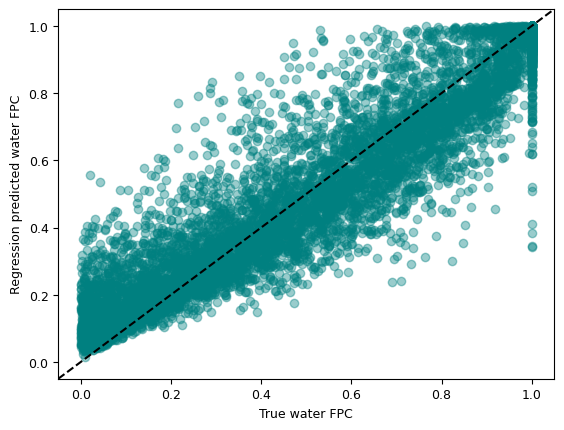

Brown_algae hard classification score: 0.935923076923077
Other hard classification score: 0.9148461538461539


In [10]:
pipe = unmix.UnmixPixels(x_train, y_train, x_test, y_test, presence_absence_thresh= 0.2, reload = reload, reload_dict= reload_dict)
presence_probas, water_pred = pipe.classify_presence(classifier_params= RF_classifier_params, regressor_params= RF_regressor_params, plot = "water")

In [11]:
# Store classifications and water reg results
train_probas = pd.DataFrame({k : v for k, v in presence_probas["train"].items()})
train_probas.set_index(x_train.index, inplace = True)
test_probas = pd.DataFrame({k : v for k, v in presence_probas["test"].items()})
test_probas.set_index(x_test.index, inplace = True)

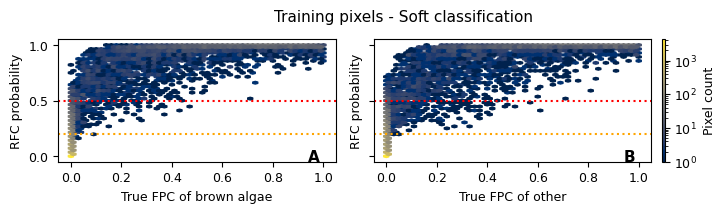

In [12]:
# Plot soft classification results - TRAINING
plotting_params = {
    "x_array": y_train.iloc[:, :-1], 
    "y_array": train_probas, 
    "alpha": 0.2, # p[:,-1],
    "metric" : "MAE", 
    "colour": colours, #p[:,-1], y_train.iloc[:, -1],
    "cmap" : "cividis", 
    "fig_title" : "Training pixels - Soft classification",
    "x_axis_label": "True FPC",
    "y_axis_label" : "RFC probability", 
    "stats_values" : None,
    "line_1_1" : False, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "h_lines" : [(0.2, "orange"), (0.5, "red")],
    "save" : savefigall,
    "type" : "hexbin",
    "output_dir" : plot_output_dir,
    "output_name" : "train_soft_classification",
    "annotation_xy" : (0.05, 0.70),

}

if y_test.shape[1] > 8: 
    plotting_params["figrows"] = min(len(y_test.columns)-1, 5)
    plotting_params["figsize"]= 2
    plot_multi_result_huge(**plotting_params)
else: 
    plotting_params["figsize"] = (4,2)
    plot_multi_result(**plotting_params)


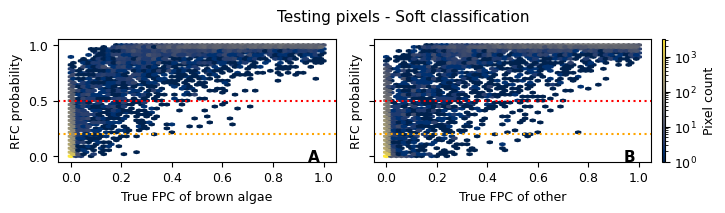

In [13]:
# Plot soft classification results - TESTING
plotting_params = {
    "x_array": y_test.iloc[:, :-1], 
    "y_array": test_probas, 
    "alpha": 0.2, # p[:,-1],
    "metric" : "MAE", 
    "colour": y_test.iloc[:, -1], #colours, #p[:,-1],
    "cmap" : "cividis", 
    "fig_title" : "Testing pixels - Soft classification",
    "x_axis_label": "True FPC",
    "y_axis_label" : "RFC probability", 
    "stats_values" : None,
    "line_1_1" : False, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "h_lines" : [(0.2, "orange"), (0.5, "red")],
    "save" : savefigall,
    "type" : "hexbin",
    "output_dir" : plot_output_dir,
    "output_name" : "test_soft_classification",
    "annotation_xy" : (0.05, 0.70),

}

if y_test.shape[1] > 8: 
    plotting_params["figrows"] = min(len(y_test.columns)-1, 5)
    plotting_params["figsize"]= 2
    plot_multi_result_huge(**plotting_params)
else: 
    plotting_params["figsize"] = (4,2)
    plot_multi_result(**plotting_params)

# Filter and regress

In [14]:
regressor_predictions = pipe.filter_and_regress(plot = "none", regressor_params= RF_regressor_params)

# Store regression results
train_regressions = pd.DataFrame({k : v for k, v in regressor_predictions["train"].items()})
test_regressions = pd.DataFrame({k : v for k, v in regressor_predictions["test"].items()})

In [15]:
# Combine classification and regression results by soft threshold
train_results = combine_class_regression(train_probas, 
                                         train_regressions, 
                                         water_pred["train"], 
                                         0.2)
test_results = combine_class_regression(test_probas, 
                                        test_regressions, 
                                        water_pred["test"],
                                        0.2)

# Adjust for unity
train_results.replace(np.nan, 0, inplace = True)
test_results.replace(np.nan, 0, inplace = True)

# Calculate evaluation stats
train_stats = calc_eval_stats(pipe.y_train, train_results, include_zeros= False)
test_stats = calc_eval_stats(pipe.y_test, test_results, include_zeros = False)

# force Dataframes to have numeric dtypes
train_results = train_results.astype("float64")
test_results = test_results.astype("float64")

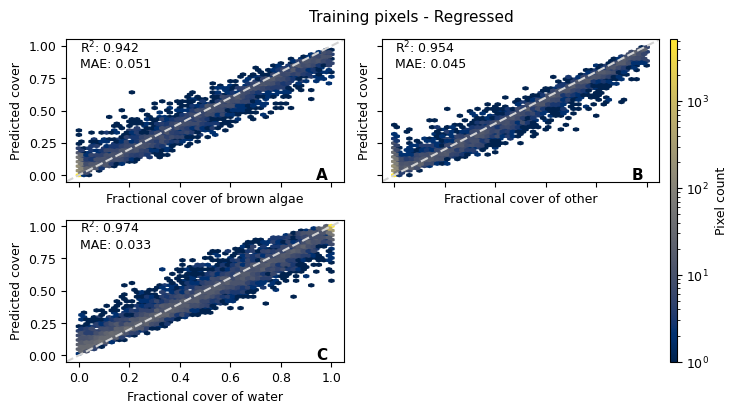

In [16]:
# Plot training regressor results

plotting_params = {
    "x_array": y_train, 
    "y_array": train_results, 
    "alpha": 1, # p[:,-1],
    "metric" : "MAE", 
    "colour":train_results.iloc[:, 0], #p[:,-1],
    "cmap" : "cividis", 
    "fig_title" : "Training pixels - Regressed",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "type" : "hexbin", 
    "stats_values" : train_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "save" : savefigall,
    "output_dir" : plot_output_dir, 
    "output_name": "train_results",
    "annotation_xy" : (0.05, 0.80),
}

if y_test.shape[1] > 8: 
    plotting_params["figrows"] = min(len(y_test.columns)-1, 5)
    plotting_params["figsize"]= 2
    plot_multi_result_huge(**plotting_params)
else: 
    plotting_params["figsize"] = (4,2)
    plot_multi_result(**plotting_params)

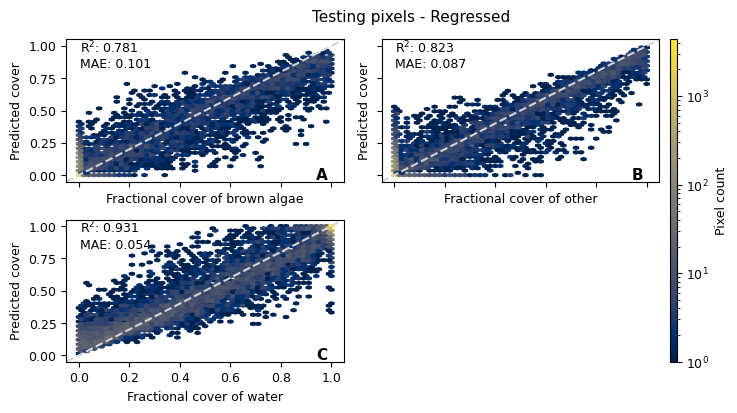

In [17]:
# Plot testing regressor and classifier results
plotting_params = {
    "x_array": y_test, 
    "y_array": test_results, 
    "alpha": 1,
    "metric" : "MAE", 
    "colour":test_results.iloc[:, -1],
    "cmap" : "cividis", 
    "fig_title" : "Testing pixels - Regressed",
    "x_axis_label": "Fractional cover",
    "y_axis_label" : "Predicted cover", 
    "stats_values" : test_stats,
    "type": "hexbin",
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "save" : savefigall,
    "output_dir" : plot_output_dir, 
    "output_name": "test_results",
    "annotation_xy" : (0.05, 0.80),
}

if y_test.shape[1] > 8: 
    plotting_params["figrows"] = min(len(y_test.columns)-1, 5)
    plotting_params["figsize"]= 2
    plot_multi_result_huge(**plotting_params)
else: 
    plotting_params["figsize"] = (4,2)
    plot_multi_result(**plotting_params)

# Regression specificity
Check for specificity (i.e. false positives) issues with the regression data. The regression will produce a value for all pixels run through out, often ending up with small predicted values where zero should have been returned because of spectral similarity between classes. 

In [18]:
# Import spectra
spectra = pd.read_csv(spec_lib_path, index_col = 0)
if sensor_code == "S2":
    spectra.columns = [x[10:] for x in spectra.columns]
elif sensor_code.lower() == "psd":
    spectra.columns = [x[:-9] for x in spectra.columns]

Thresholding by false positive share.
Endmembers producing more than 1.2 % of false positives will be identified.


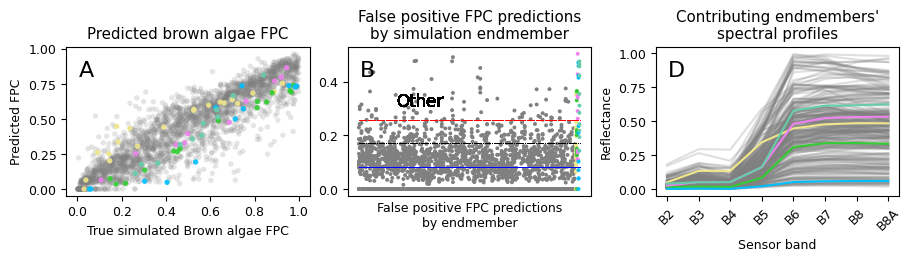

In [19]:
if class_code.lower() == "class": 
    cols_to_plot = ["undaria", "ecklonia", "durvillaea", "ulva", "filamentous_rhodophyte", "rock"]
    sensi_col = "macrocystis"
    ax_height = 1.5
else: 
    cols_to_plot = None
    ax_height = 2
    sensi_col = pipe.y_test.columns[0]
pipe.plot_sensitivity_no_water(predicted_values = test_results, 
                      sensi_col = sensi_col, 
                      FP_thresh_mode= "share", FP_thresh = 3, spectra = spectra, possible_colours = possible_colours, true_y = pipe.y_test, endmembers= endmember_indices, savefig= savefigall, plot_output_dir= plot_output_dir, ax_height= ax_height, cols_to_plot = cols_to_plot)

In [20]:
# check out the effects of false_positive detections
counts_FP, mean_FP, std_FP, mean_std_FP = pipe.check_sensitivity(test_results)

sensitivity_determination = pd.concat([counts_FP, mean_FP, std_FP], axis = 0, keys = ["pixel counts", "mean", "standard dev"])

sensitivity_determination.to_csv(f"{plot_output_dir}False_positive_evaluations.csv")
        
print(f"The mean false positive detection value plus one standard deviation of those detections is: \n {std_FP}")

The mean false positive detection value plus one standard deviation of those detections is: 
             brown_algae     other
brown_algae         NaN  0.086325
other          0.076013       NaN
average        0.076013  0.086325


In [21]:
# Apply sensitivity threshold 
test_predictions = pipe.apply_sensitivity(test_results, sensitivity_thresholds= mean_FP.loc["average", :])

test_sensitivity_stats = calc_eval_stats(pipe.y_test, test_predictions, include_zeros= False)

zeros_test_sensitivity_stats = calc_eval_stats(pipe.y_test, test_predictions, include_zeros= True)

# Fitting curves and inverting

In [22]:
fitted_curves, all_stats, all_curves = pipe.fit_all_curves(test_predictions)

Best fit curve is a Sigmoid for brown algae with R2 = 0.8285
Best fit curve is a Sigmoid for other with R2 = 0.872
Sigmoid fit failed, defaulting to linear.
Best fit curve is a Linear for water with R2 = 0.9322


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

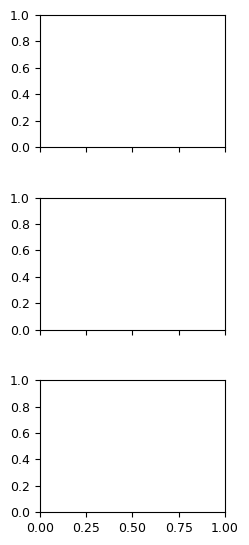

In [23]:
# Plot fitted curves and regression results
results_df = test_predictions
criterion = ("R2", "max")

ax_height = 2
n_rows = 1

n_cols = pipe.y_test.shape[1]
fig_cols = n_cols // n_rows if n_cols%n_rows == 0 else n_cols // n_rows + 1

# Create a figure and subplot axes
fig, ax = plt.subplots(
    n_rows,
    fig_cols,
    figsize=(3*fig_cols, n_rows * ax_height),
    sharex=True,
    sharey=True)

fig.tight_layout(pad = 3)

for col in range(n_cols):
    col_name = pipe.y_test.columns[col]
    row_i, col_i = divmod(col, fig_cols)
    x = pipe.y_test[pipe.y_test[col_name] > 0]
    y = np.array(results_df[y_test[col_name] >0])
    col_name = x.columns[col]
    
    class_curves = all_curves.get(col_name)
    class_stats = all_stats.get(col_name)
    x_linspace = np.linspace(np.min(x), np.max(x), 500)
    
    if class_curves.get("sigmoid") is None:
        y_linspace = {
        "linear" : class_curves["linear"][0]*x_linspace + class_curves["linear"][1]
        }
    else:
        y_linspace = {
            "sigmoid": sigmoid(x_linspace, *class_curves.get("sigmoid")),"linear" : class_curves["linear"][0]*x_linspace + class_curves["linear"][1]
        }
    
    ax[row_i, col_i].scatter(x[col_name], y[:,col], alpha = 0.2, c = colours.get(col_name, "gray"), s = 10)
    ax[row_i, col_i].set_xlabel(f"True FPC")
    ax[row_i, col_i].set_ylabel ("Predicted FPC")
    ax[row_i, col_i].axline((0,0), slope = 1, color = "darkslategrey", alpha = 1, linestyle = "--")
    ax[row_i, col_i].annotate(
            col_name.replace("_"," ").capitalize(),
            xy=(0.0, 1.02),
            xycoords="axes fraction",
            color = "black",
            fontsize = 10 if len(col_name) < 18 else 9
        )
    if class_curves.get("sigmoid") is not None:
        ax[row_i, col_i].plot(x_linspace, y_linspace["sigmoid"], '--', color = "red", label='Fitted curve - Sigmoid')
    ax[row_i, col_i].plot(x_linspace, y_linspace["linear"], ':', color = "black", label='Fitted curve - Linear')

    if class_curves.get("sigmoid") is not None:
        ax[row_i, col_i].annotate(r'$\mathregular{R^2}$'f"\nSig: {class_stats["sigmoid"][criterion[0]][0]:.3f} \nLin: {class_stats["linear"][criterion[0]][0]:.3f}", xy = (0.03, 0.66), xycoords = "axes fraction", fontsize = 9,)
    else:
        ax[row_i, col_i].annotate(r'$\mathregular{R^2}$'f"\nSig: undefined \nLin: {class_stats["linear"][criterion[0]][0]:.3f}", xy = (0.03, 0.66), xycoords = "axes fraction", fontsize = 9,)
        
    if x.shape[1] % 2 == 1:
        ax[-1, -1].set_visible(False)  
    fig.suptitle("Fitting curves to regression results", y = 1)
if savefigall:
    plt.savefig(f"{plot_output_dir}fitting_curves.svg")
    plt.savefig(f"{plot_output_dir}fitting_curves.png")   
plt.show()


In [24]:
# Inverted predictions by best curve function
inverted = pipe.apply_inversion(test_predictions)

# Adjust for unit area
inverted_adjusted = inverted.div(inverted.sum(axis = 1), axis = 0)

# Calculate evaluation statistics
inv_adj_stats = calc_eval_stats(pipe.y_test, inverted_adjusted, include_zeros= False)

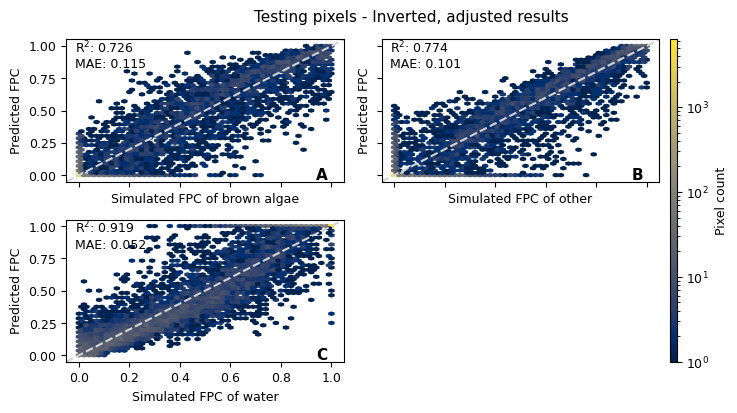

In [25]:
plotting_params = {
    "x_array": y_test, 
    "y_array": inverted_adjusted, 
    "alpha": 0.3, 
    "colour": y_test.iloc[:,-1],
    "metric" : "MAE",
    "cmap" : "cividis", 
    "fig_title" : f"Testing pixels - Inverted, adjusted results",
    "x_axis_label": "Simulated FPC",
    "y_axis_label" : "Predicted FPC", 
    "stats_values" : inv_adj_stats, 
    "line_1_1" : True,
    "type": "hexbin",
    "sensor_code" : sensor_code,
    "class_code" : class_code, 
    "save" : savefigall,
    "output_dir" : "./plots/regression/evaluation/", 
    "output_name": "Testing_inv_adj",
    "figsize" : (4,2), 
    "annotation_xy" : (0.03, 0.80),
}

if y_test.shape[1] > 8: 
    plotting_params["figrows"] = min(len(y_test.columns)-1, 5)
    plotting_params["figsize"]= 2
    plot_multi_result_huge(**plotting_params)
else: 
    plotting_params["figsize"] = (4,2)
    plot_multi_result(**plotting_params)

# Run Chained classification-regression on new data

In [26]:
# Follow normal workflow for unseen data
valid_sim_pix = np.load(sim_pix_directory + "unseen_pixels.npy")
valid_pixel_fpcs = pd.DataFrame(np.load(sim_pix_directory + "unseen_pixel_fpcs.npy"))
valid_endmember_indices = np.load(sim_pix_directory + "unseen_pixel_endmembers.npy")
valid_pixel_fpcs.columns = columns

# Decompose new pixels into the PCA components
deco_valid_sim_pix = pd.DataFrame(deco.transform(valid_sim_pix))

# Unmix using the classifier and regressor pipeline
valid_pixel_classifications, valid_water, valid_pixel_regressions = pipe.unmix_new_data(deco_valid_sim_pix, columns, sensitivity_thresholds= None)

# Make any pixel not classified as present have zero cover
valid_results = combine_class_regression(valid_pixel_classifications, valid_pixel_regressions, valid_water, 0.2)

# Apply sensitivity thresholds
valid_threshed_results = pipe.apply_sensitivity(valid_results, mean_FP.loc["average", :])

# Invert predictions using established inversion functions
valid_inverted = pipe.apply_inversion(valid_threshed_results)

# Adjust for unit area
valid_inverted_adjusted = valid_inverted.div(valid_inverted.sum(axis = 1), axis = 0)

# Calculate stats
valid_inv_adj_stats = calc_eval_stats(valid_pixel_fpcs, 
                                    valid_inverted_adjusted, 
                                    include_zeros = False)

c:\Users\s4770224\Documents\GitHub\Spectral-Analysis\separability_venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


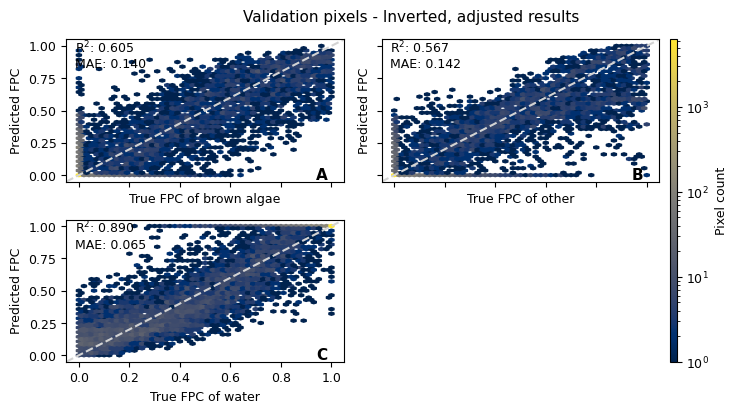

In [27]:
# Plot  results coloured by class FPC
col = -1
plotting_params = {
    "x_array": valid_pixel_fpcs, 
    "y_array": valid_inverted_adjusted, 
    "alpha": 0.5, #valid_p[:,-1],
    "colour": valid_pixel_fpcs.iloc[:, col], 
    "metric": "MAE",
    "cmap" : "cividis", 
    "fig_title" : f"Validation pixels - Inverted, adjusted results",
    "x_axis_label": "True FPC",
    "y_axis_label" : "Predicted FPC", 
    "stats_values" : valid_inv_adj_stats,
    "line_1_1" : True, 
    "sensor_code" : sensor_code,
    "class_code" : class_code,
    "type" : "hexbin", 
    "save" : savefigall,
    "figsize" : (4,2), 
    "output_dir" : plot_output_dir, 
    "output_name": f"validation_inv_adj", 
    "annotation_xy" : (0.03, 0.80),

}

if y_test.shape[1] > 8: 
    plotting_params["figrows"] = min(len(y_test.columns)-1, 5)
    plotting_params["figsize"]= 2
    plot_multi_result_huge(**plotting_params)
else: 
    plotting_params["figsize"] = (4,2)
    plot_multi_result(**plotting_params)

In [28]:
# Calculate the extra bloat and deficit caused by false detections

# Find all pixels truly simulated and positively predicted - TESTING
positive_sim = pipe.y_test >0
positives_pred = inverted_adjusted > 0

# find false positives and negatives
false_posi = np.logical_and(~positive_sim, positives_pred)
false_negs = np.logical_and(positive_sim, ~positives_pred)

# Quantify errors as percents of simulated 
false_posi_bloat = inverted_adjusted*false_posi
false_negs_deficit = pipe.y_test* false_negs
bloat = false_posi_bloat.sum()/pipe.y_test.sum() *100
deficit = false_negs_deficit.sum()/pipe.y_test.sum() *100


# Find all pixels truly simulated and positively predicted - Validation
positive_sim = valid_pixel_fpcs >0
positives_pred = valid_inverted_adjusted > 0

# find false positives and negatives
false_posi = np.logical_and(~positive_sim, positives_pred)
false_negs = np.logical_and(positive_sim, ~positives_pred)

# Quantify errors as percents of simulated 
false_posi_bloat = valid_inverted_adjusted*false_posi
false_negs_deficit = valid_pixel_fpcs* false_negs
bloat_vali = false_posi_bloat.sum()/valid_inverted_adjusted.sum() *100
deficit_vali = false_negs_deficit.sum()/valid_pixel_fpcs.sum() *100

# Print and save results
FP_impact = pd.DataFrame([bloat, deficit, bloat_vali, deficit_vali], index = ["bloat", "deficit", "bloat_vali", "deficit_vali"], columns = pixel_fpcs.columns)
FP_impact.to_csv(f"{plot_output_dir}bloat_deficit.csv", index = True)

In [29]:
#re-calculate workflow stats with zeros then concat
train_stats_zeros = calc_eval_stats(pipe.y_train,
                                    train_results,
                                    include_zeros= True)
test_stats_zeros = calc_eval_stats(pipe.y_test,
                                   test_results,
                                   include_zeros = True)
inv_adj_stats_zeros = calc_eval_stats(pipe.y_test,
                                      inverted_adjusted,
                                      include_zeros= True)
valid_inv_adj_stats_zeros = calc_eval_stats(valid_pixel_fpcs,
                                          valid_inverted_adjusted,
                                          include_zeros = True)

# concat all eval stats to export to CSV

all_eval_stats = pd.concat([pd.DataFrame(train_stats, index = pipe.y_test.columns),
                            pd.DataFrame(test_stats, index = pipe.y_test.columns),
                            pd.DataFrame(test_sensitivity_stats, index = pipe.y_test.columns),
                            pd.DataFrame(inv_adj_stats, index = pipe.y_test.columns),
                            pd.DataFrame(valid_inv_adj_stats, index = pipe.y_test.columns),
                            pd.DataFrame(train_stats_zeros, index = pipe.y_test.columns),
                            pd.DataFrame(test_stats_zeros, index = pipe.y_test.columns),
                             pd.DataFrame(zeros_test_sensitivity_stats, index = pipe.y_test.columns),
                            pd.DataFrame(inv_adj_stats_zeros, index = pipe.y_test.columns),
                            pd.DataFrame(valid_inv_adj_stats_zeros, index = pipe.y_test.columns),], axis = 0, ignore_index= False, keys=[
                                "Training - Regressed",
                                "Testing - Regressed",
                                "Testing - Sensitivity Thresholded",
                                "Testing - Inverted, Adjusted",
                                "Valiadation - Inverted, Adjusted",
                                "Training - Regressed (0-inflated)",
                                "Testing - Regressed (0-inflated)",
                                "Testing - Sensitivity Thresholded (0-inflated)",
                                "Testing - Inverted, Adjusted (0-inflated)",
                                "Validation - Inverted, Adjusted (0-inflated)",
                            ])

if savefigall:
    all_eval_stats.to_csv(f"{plot_output_dir}all_eval_statistics.csv", index = True)

# Calculate curve inversion stats

In [30]:
inversion_results = {
    "test_results": {},
    "validation_results": {}
}
inversion_stats = {
    "test_results": {},
    "validation_results": {}
}

data_dict = {
    "test_results": {
        "true": y_test,
        "pred": test_results,
    },
    "validation_results": {
        "true": valid_pixel_fpcs,
        "pred": valid_threshed_results,
    },}

In [31]:
for key in inversion_results:
    for curve in ["linear", "sigmoid"]:
        inversion_results[key][curve] = pipe.apply_inversion(data_dict[key]["pred"], force_fit= curve)
        inversion_stats[key][curve] = calc_eval_stats(data_dict[key]["true"], inversion_results[key][curve])

In [33]:
# Drop unwanted metrics
for key in inversion_stats.keys():
   for key2 in inversion_stats[key].keys():
      del inversion_stats[key][key2]["RMSE"]
      del inversion_stats[key][key2]["MSE"]

# Unpack nested inversion stats dictionary
reform = {(outerKey, innerKey): values for outerKey, innerDict in inversion_stats.items() for innerKey, values in innerDict.items()}
reform_2 = {(outerKey[0], outerKey[1], innerKey): values for outerKey, innerDict in reform.items() for innerKey, values in innerDict.items()}

# Format as DataFrame
f = pd.DataFrame.from_dict(reform_2, orient = "columns").set_index(pipe.y_test.columns)
if savefigall:
   f.to_csv(f"{plot_output_dir}inversion_curve_choice_stats.csv")


# Save trained models

In [35]:
if reload == False: 
    joblib.dump(pipe.classifiers, plot_output_dir+"classifiers.joblib", compress = 3)
    joblib.dump(pipe.regressors, plot_output_dir+"regressors.joblib", compress = 3)
    joblib.dump(pipe.water_regressor, plot_output_dir+"water_regressor.joblib", compress = 3)
    np.save(plot_output_dir + "test_indices", pipe.y_test.index)
    np.save(plot_output_dir + "train_indices", pipe.y_train.index)